In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import time

In [ ]:
# Base class for RNN architectures
class BaseRNN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = lr
        
        # Output layer (common to all)
        self.Wy = np.random.randn(output_size, hidden_size) * 0.1
        self.by = np.zeros((output_size, 1))
        
        # For tracking
        self.train_losses = []
        self.val_losses = []
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def sigmoid_derivative(self, sigmoid_output):
        return sigmoid_output * (1 - sigmoid_output)
    
    def tanh(self, x):
        return np.tanh(x)
    
    def tanh_derivative(self, tanh_output):
        return 1 - tanh_output**2
    
    def forward(self, inputs):
        raise NotImplementedError
    
    def backward(self, inputs, targets):
        raise NotImplementedError
    
    def train_step(self, sequences, targets):
        total_loss = 0
        for seq, target in zip(sequences, targets):
            # Forward pass
            outputs, cache = self.forward(seq)
            
            # Compute loss
            loss = 0
            for o, t in zip(outputs, target):
                loss += np.sum((o - t.reshape(-1, 1))**2)
            total_loss += loss
            
            # Backward pass
            self.backward(seq, target, outputs, cache)
        
        return total_loss / len(sequences)
    
    def predict(self, sequence):
        outputs, _ = self.forward(sequence)
        return [o.ravel() for o in outputs]

In [ ]:
# Vanilla RNN Implementation
class VanillaRNN(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        super().__init__(input_size, hidden_size, output_size, lr)
        
        self.Wx = np.random.randn(hidden_size, input_size) * 0.1
        self.Wh = np.random.randn(hidden_size, hidden_size) * 0.1
        self.bh = np.zeros((hidden_size, 1))
    
    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        hiddens = []
        outputs = []
        pre_activations = []
        
        for x in inputs:
            x = x.reshape(-1, 1)
            hiddens.append(h)  # Store previous hidden state
            pre_h = self.Wx @ x + self.Wh @ h + self.bh
            h = self.tanh(pre_h)
            y = self.Wy @ h + self.by
            
            pre_activations.append(pre_h)
            outputs.append(y)
        
        cache = (hiddens, pre_activations)
        return outputs, cache
    
    def backward(self, inputs, targets, outputs, cache):
        hiddens, pre_activations = cache
        
        # Initialize gradients
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        dbh = np.zeros_like(self.bh)
        dWy = np.zeros_like(self.Wy)
        dby = np.zeros_like(self.by)
        
        dh_next = np.zeros((self.hidden_size, 1))
        
        # Backpropagation through time
        for t in reversed(range(len(inputs))):
            x = inputs[t].reshape(-1, 1)
            h_prev = hiddens[t]
            pre_h = pre_activations[t]
            h = self.tanh(pre_h)
            y = outputs[t]
            target = targets[t].reshape(-1, 1)
            
            # Output layer gradients
            dy = 2 * (y - target)  # MSE gradient
            dWy += dy @ h.T
            dby += dy
            
            # Hidden layer gradients
            dh = self.Wy.T @ dy + dh_next
            dh_raw = self.tanh_derivative(h) * dh
            
            dbh += dh_raw
            dWx += dh_raw @ x.T
            dWh += dh_raw @ h_prev.T
            
            dh_next = self.Wh.T @ dh_raw
        
        # Gradient clipping
        for grad in [dWx, dWh, dbh, dWy, dby]:
            np.clip(grad, -5, 5, out=grad)
        
        # Update parameters
        self.Wx -= self.lr * dWx / len(inputs)
        self.Wh -= self.lr * dWh / len(inputs)
        self.bh -= self.lr * dbh / len(inputs)
        self.Wy -= self.lr * dWy / len(inputs)
        self.by -= self.lr * dby / len(inputs)

In [ ]:
# LSTM Implementation
class LSTM(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        super().__init__(input_size, hidden_size, output_size, lr)
        
        concat_size = input_size + hidden_size
        
        # LSTM gates
        self.Wf = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wi = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wc = np.random.randn(hidden_size, concat_size) * 0.1
        self.Wo = np.random.randn(hidden_size, concat_size) * 0.1
        
        self.bf = np.zeros((hidden_size, 1))
        self.bi = np.zeros((hidden_size, 1))
        self.bc = np.zeros((hidden_size, 1))
        self.bo = np.zeros((hidden_size, 1))
    
    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        c = np.zeros((self.hidden_size, 1))
        
        hiddens = []
        cells = []
        outputs = []
        caches = []
        
        for x in inputs:
            x = x.reshape(-1, 1)
            concat = np.vstack((h, x))
            
            # Gates computation
            f_gate = self.sigmoid(self.Wf @ concat + self.bf)
            i_gate = self.sigmoid(self.Wi @ concat + self.bi)
            c_tilde = self.tanh(self.Wc @ concat + self.bc)
            o_gate = self.sigmoid(self.Wo @ concat + self.bo)
            
            # Cell state and hidden state
            c = f_gate * c + i_gate * c_tilde
            h = o_gate * self.tanh(c)
            
            # Output
            y = self.Wy @ h + self.by
            
            # Store for backward pass
            hiddens.append(h)
            cells.append(c)
            outputs.append(y)
            caches.append((x, h, c, f_gate, i_gate, c_tilde, o_gate, concat))
        
        return outputs, caches
    
    def backward(self, inputs, targets, outputs, caches):
        # Initialize gradients
        dWf = np.zeros_like(self.Wf)
        dWi = np.zeros_like(self.Wi)
        dWc = np.zeros_like(self.Wc)
        dWo = np.zeros_like(self.Wo)
        dbf = np.zeros_like(self.bf)
        dbi = np.zeros_like(self.bi)
        dbc = np.zeros_like(self.bc)
        dbo = np.zeros_like(self.bo)
        dWy = np.zeros_like(self.Wy)
        dby = np.zeros_like(self.by)
        
        dh_next = np.zeros((self.hidden_size, 1))
        dc_next = np.zeros((self.hidden_size, 1))
        
        # Backpropagation through time
        for t in reversed(range(len(inputs))):
            # Unpack cache
            x, h, c, f_gate, i_gate, c_tilde, o_gate, concat = caches[t]
            c_prev = caches[t-1][2] if t > 0 else np.zeros((self.hidden_size, 1))
            
            y = outputs[t]
            target = targets[t].reshape(-1, 1)
            
            # Output layer gradients
            dy = 2 * (y - target)
            dWy += dy @ h.T
            dby += dy
            
            # Hidden state gradient
            dh = self.Wy.T @ dy + dh_next
            
            # Output gate gradient
            do = dh * self.tanh(c)
            do_raw = self.sigmoid_derivative(o_gate) * do
            dWo += do_raw @ concat.T
            dbo += do_raw
            
            # Cell state gradient
            dc = dh * o_gate * self.tanh_derivative(self.tanh(c)) + dc_next
            
            # Cell input gradient
            dc_tilde = dc * i_gate
            dc_tilde_raw = self.tanh_derivative(c_tilde) * dc_tilde
            dWc += dc_tilde_raw @ concat.T
            dbc += dc_tilde_raw
            
            # Input gate gradient
            di = dc * c_tilde
            di_raw = self.sigmoid_derivative(i_gate) * di
            dWi += di_raw @ concat.T
            dbi += di_raw
            
            # Forget gate gradient
            df = dc * c_prev
            df_raw = self.sigmoid_derivative(f_gate) * df
            dWf += df_raw @ concat.T
            dbf += df_raw
            
            # Gradients for next timestep
            dconcat = self.Wf.T @ df_raw + self.Wi.T @ di_raw + self.Wc.T @ dc_tilde_raw + self.Wo.T @ do_raw
            dh_next = dconcat[:self.hidden_size]
            dc_next = dc * f_gate
        
        # Gradient clipping
        for grad in [dWf, dWi, dWc, dWo, dbf, dbi, dbc, dbo, dWy, dby]:
            np.clip(grad, -5, 5, out=grad)
        
        # Update parameters
        scale = 1.0 / len(inputs)
        self.Wf -= self.lr * dWf * scale
        self.Wi -= self.lr * dWi * scale
        self.Wc -= self.lr * dWc * scale
        self.Wo -= self.lr * dWo * scale
        self.bf -= self.lr * dbf * scale
        self.bi -= self.lr * dbi * scale
        self.bc -= self.lr * dbc * scale
        self.bo -= self.lr * dbo * scale
        self.Wy -= self.lr * dWy * scale
        self.by -= self.lr * dby * scale


In [ ]:
# GRU Implementation
class GRU(BaseRNN):
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        super().__init__(input_size, hidden_size, output_size, lr)
        
        concat_size = input_size + hidden_size
        
        # GRU gates
        self.Wz = np.random.randn(hidden_size, concat_size) * 0.1  # Update gate
        self.Wr = np.random.randn(hidden_size, concat_size) * 0.1  # Reset gate
        self.Wh = np.random.randn(hidden_size, concat_size) * 0.1  # Candidate hidden state
        
        self.bz = np.zeros((hidden_size, 1))
        self.br = np.zeros((hidden_size, 1))
        self.bh = np.zeros((hidden_size, 1))
    
    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        
        hiddens = []
        outputs = []
        caches = []
        
        for x in inputs:
            x = x.reshape(-1, 1)
            h_prev = h
            concat = np.vstack((h_prev, x))
            
            # Gates
            z_gate = self.sigmoid(self.Wz @ concat + self.bz)  # Update gate
            r_gate = self.sigmoid(self.Wr @ concat + self.br)  # Reset gate
            
            # Candidate hidden state
            concat_reset = np.vstack((r_gate * h_prev, x))
            h_tilde = self.tanh(self.Wh @ concat_reset + self.bh)
            
            # New hidden state
            h = (1 - z_gate) * h_prev + z_gate * h_tilde
            
            # Output
            y = self.Wy @ h + self.by
            
            hiddens.append(h)
            outputs.append(y)
            caches.append((x, h_prev, h, z_gate, r_gate, h_tilde, concat, concat_reset))
        
        return outputs, caches
    
    def backward(self, inputs, targets, outputs, caches):
        # Initialize gradients
        dWz = np.zeros_like(self.Wz)
        dWr = np.zeros_like(self.Wr)
        dWh = np.zeros_like(self.Wh)
        dbz = np.zeros_like(self.bz)
        dbr = np.zeros_like(self.br)
        dbh = np.zeros_like(self.bh)
        dWy = np.zeros_like(self.Wy)
        dby = np.zeros_like(self.by)
        
        dh_next = np.zeros((self.hidden_size, 1))
        
        # Backpropagation through time
        for t in reversed(range(len(inputs))):
            # Unpack cache
            x, h_prev, h, z_gate, r_gate, h_tilde, concat, concat_reset = caches[t]
            
            y = outputs[t]
            target = targets[t].reshape(-1, 1)
            
            # Output layer gradients
            dy = 2 * (y - target)
            dWy += dy @ h.T
            dby += dy
            
            # Hidden state gradient
            dh = self.Wy.T @ dy + dh_next
            
            # Update gate gradients
            dh_prev_from_z = dh * (1 - z_gate)
            dh_tilde = dh * z_gate
            dz = dh * (h_tilde - h_prev)
            dz_raw = self.sigmoid_derivative(z_gate) * dz
            dWz += dz_raw @ concat.T
            dbz += dz_raw
            
            # Candidate hidden state gradients
            dh_tilde_raw = self.tanh_derivative(h_tilde) * dh_tilde
            dWh += dh_tilde_raw @ concat_reset.T
            dbh += dh_tilde_raw
            
            # Reset gate gradients
            dconcat_reset = self.Wh.T @ dh_tilde_raw
            dr_times_h = dconcat_reset[:self.hidden_size]
            dr = dr_times_h * h_prev
            dr_raw = self.sigmoid_derivative(r_gate) * dr
            dWr += dr_raw @ concat.T
            dbr += dr_raw
            
            # Previous hidden state gradient
            dh_prev_from_r = dr_times_h * r_gate
            dconcat_from_z = self.Wz.T @ dz_raw
            dconcat_from_r = self.Wr.T @ dr_raw
            
            dh_next = dh_prev_from_z + dh_prev_from_r + dconcat_from_z[:self.hidden_size] + dconcat_from_r[:self.hidden_size]
        
        # Gradient clipping
        for grad in [dWz, dWr, dWh, dbz, dbr, dbh, dWy, dby]:
            np.clip(grad, -5, 5, out=grad)
        
        # Update parameters
        scale = 1.0 / len(inputs)
        self.Wz -= self.lr * dWz * scale
        self.Wr -= self.lr * dWr * scale
        self.Wh -= self.lr * dWh * scale
        self.bz -= self.lr * dbz * scale
        self.br -= self.lr * dbr * scale
        self.bh -= self.lr * dbh * scale
        self.Wy -= self.lr * dWy * scale
        self.by -= self.lr * dby * scale


In [ ]:
# Hawkes Process Simulation
class HawkesProcess:
    def __init__(self, mu=0.5, alpha=0.8, beta=1.0):
        """
        mu: baseline intensity
        alpha: excitation parameter
        beta: decay parameter
        """
        self.mu = mu
        self.alpha = alpha
        self.beta = beta
    
    def simulate(self, T=100):
        """Simulate a Hawkes process up to time T"""
        events = []
        t = 0
        
        while t < T:
            intensity = self.mu
            
            # Add contributions from past events
            for event_time in events:
                if t > event_time:
                    intensity += self.alpha * np.exp(-self.beta * (t - event_time))
            
            # Generate next event time
            u = np.random.uniform()
            inter_arrival = -np.log(u) / intensity
            t += inter_arrival
            
            if t < T:
                # Thinning step
                intensity_upper = self.mu + self.alpha * len([e for e in events if e < t])
                if np.random.uniform() < intensity / intensity_upper:
                    events.append(t)
        
        return np.array(events)
    
    def intensity_at_times(self, times, events):
        """Calculate intensity at given times"""
        intensities = []
        
        for t in times:
            intensity = self.mu
            for event_time in events:
                if t > event_time:
                    intensity += self.alpha * np.exp(-self.beta * (t - event_time))
            intensities.append(intensity)
        
        return np.array(intensities)


=== Hawkes Process RNN Comparison Analysis ===

Generating Hawkes process data...

Training models with proper backpropagation...

Epoch 1/1000
Vanilla RNN: Train Loss = 49.4825, Val Loss = 47.5922
LSTM: Train Loss = 49.4032, Val Loss = 49.1019
GRU: Train Loss = 49.8117, Val Loss = 49.4549

Epoch 2/1000

Epoch 3/1000

Epoch 4/1000

Epoch 5/1000

Epoch 6/1000

Epoch 7/1000

Epoch 8/1000

Epoch 9/1000

Epoch 10/1000

Epoch 11/1000
Vanilla RNN: Train Loss = 43.6388, Val Loss = 39.7549
LSTM: Train Loss = 48.3214, Val Loss = 47.5082
GRU: Train Loss = 45.7229, Val Loss = 43.4161

Epoch 12/1000

Epoch 13/1000

Epoch 14/1000

Epoch 15/1000

Epoch 16/1000

Epoch 17/1000

Epoch 18/1000

Epoch 19/1000

Epoch 20/1000

Epoch 21/1000
Vanilla RNN: Train Loss = 43.5225, Val Loss = 39.6158
LSTM: Train Loss = 46.9441, Val Loss = 45.4003
GRU: Train Loss = 44.4614, Val Loss = 41.0677

Epoch 22/1000

Epoch 23/1000

Epoch 24/1000

Epoch 25/1000

Epoch 26/1000

Epoch 27/1000

Epoch 28/1000

Epoch 29/1000

Ep

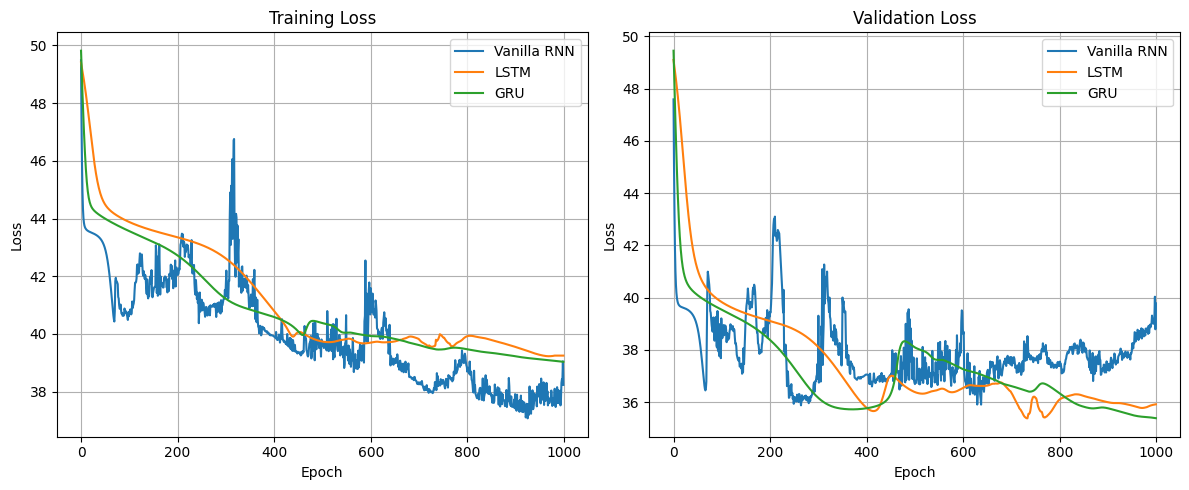

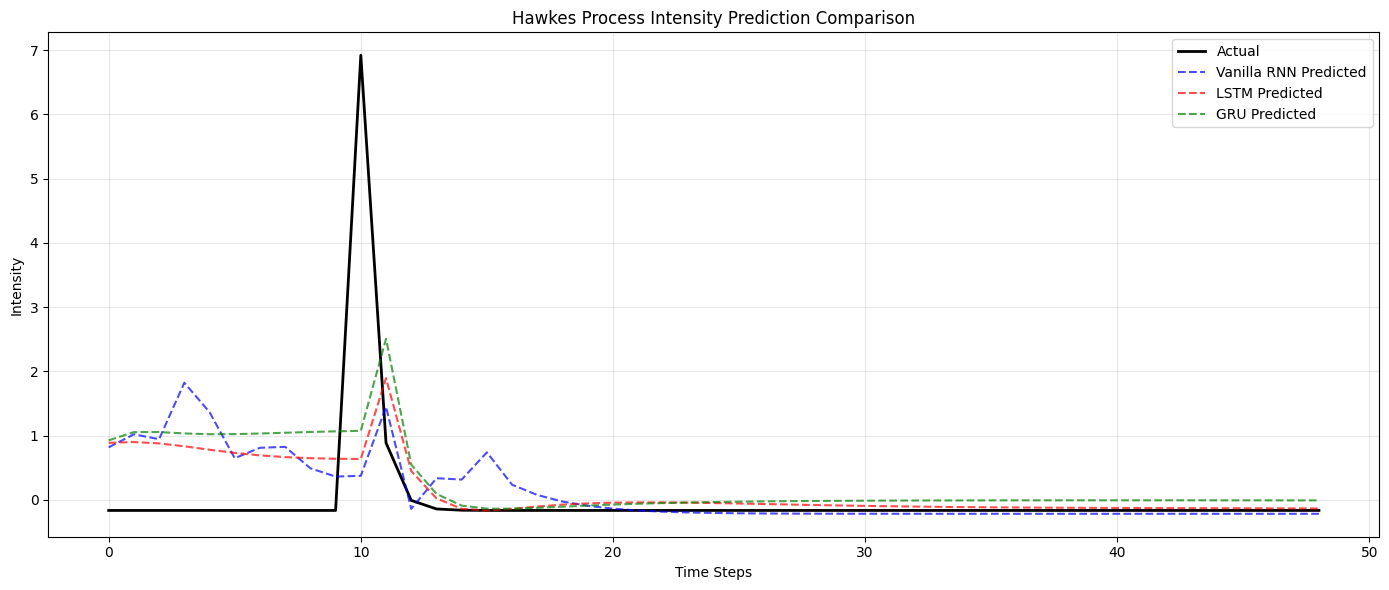

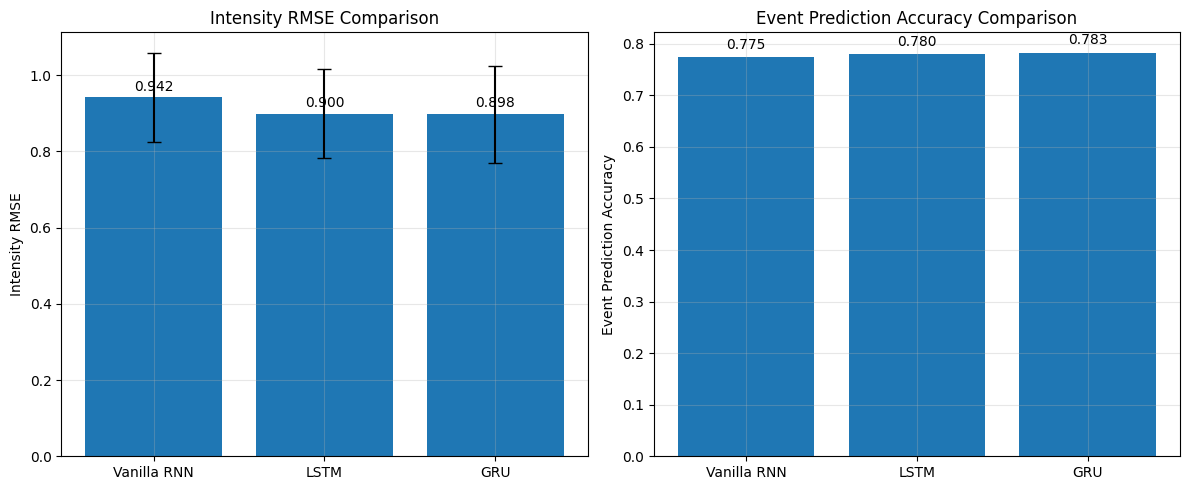


=== Summary Statistics ===

Vanilla RNN:
  Training Time: 135.20 seconds
  Final Train Loss: 38.2363
  Final Val Loss: 39.7843
  Test Intensity RMSE: 0.9420 ± 0.1176
  Event Prediction Accuracy: 0.775

LSTM:
  Training Time: 452.25 seconds
  Final Train Loss: 39.2510
  Final Val Loss: 35.9164
  Test Intensity RMSE: 0.8996 ± 0.1157
  Event Prediction Accuracy: 0.780

GRU:
  Training Time: 376.69 seconds
  Final Train Loss: 39.0362
  Final Val Loss: 35.3848
  Test Intensity RMSE: 0.8975 ± 0.1272
  Event Prediction Accuracy: 0.783


=== Scenario Analysis ===

Scenario 2: High Excitation Hawkes Process
Scenario 3: Low Baseline Hawkes Process

Evaluating on Standard scenario...

Evaluating on High Excitation scenario...

Evaluating on Low Baseline scenario...


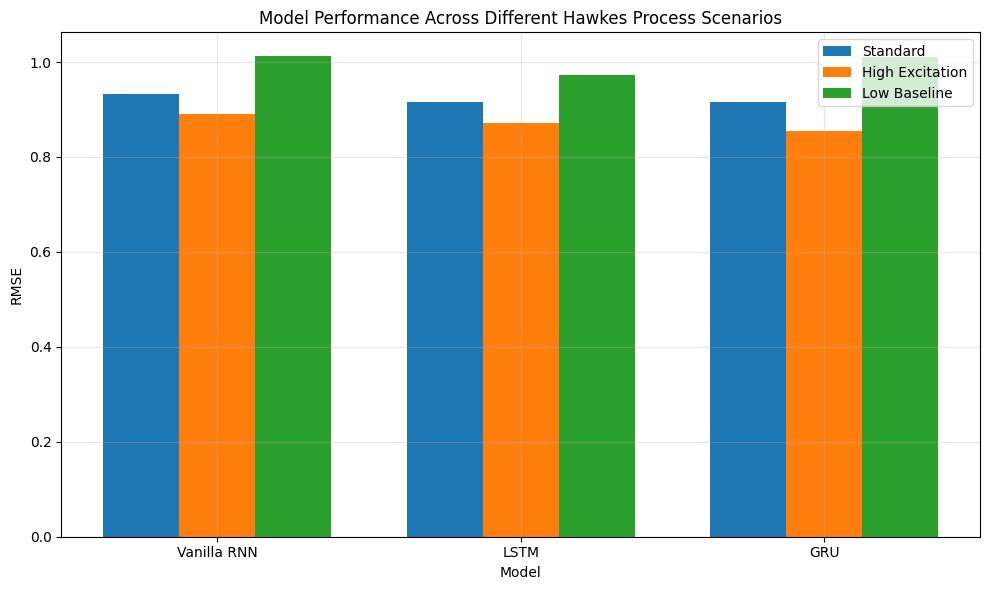

In [3]:
# Data Generation for Different Scenarios
def generate_hawkes_sequences(num_sequences=100, seq_length=50, 
                            mu_range=(0.1, 1.0), 
                            alpha_range=(0.5, 1.5), 
                            beta_range=(0.5, 2.0)):
    """Generate sequences from Hawkes processes with varying parameters"""
    sequences = []
    targets = []
    parameters = []
    
    for _ in range(num_sequences):
        # Random parameters for diversity
        mu = np.random.uniform(*mu_range)
        alpha = np.random.uniform(*alpha_range)
        beta = np.random.uniform(*beta_range)
        
        hp = HawkesProcess(mu, alpha, beta)
        events = hp.simulate(T=seq_length)
        
        # Convert to intensity sequence
        times = np.linspace(0, seq_length, seq_length)
        intensities = hp.intensity_at_times(times, events)
        
        # Normalize
        intensities = (intensities - intensities.mean()) / (intensities.std() + 1e-8)
        
        # Create input-target pairs
        seq = [np.array([intensities[i]]) for i in range(len(intensities)-1)]
        target = [np.array([intensities[i+1]]) for i in range(len(intensities)-1)]
        
        sequences.append(seq)
        targets.append(target)
        parameters.append((mu, alpha, beta))
    
    return sequences, targets, parameters


# Evaluation Metrics for Hawkes Processes
class HawkesEvaluator:
    @staticmethod
    def compute_log_likelihood(predicted_intensity, actual_events, dt=1.0):
        """Compute log-likelihood of predicted intensity given actual events"""
        log_likelihood = 0
        
        for i, event_occurred in enumerate(actual_events):
            intensity = max(predicted_intensity[i], 1e-10)
            if event_occurred:
                log_likelihood += np.log(intensity)
            log_likelihood -= intensity * dt
        
        return log_likelihood
    
    @staticmethod
    def compute_intensity_rmse(predicted, actual):
        """Root Mean Square Error of intensity predictions"""
        return np.sqrt(np.mean((predicted - actual)**2))
    
    @staticmethod
    def compute_event_prediction_accuracy(predicted_intensity, actual_events, threshold=0.5):
        """Accuracy of predicting event occurrences"""
        predicted_events = (predicted_intensity > threshold).astype(int)
        actual_binary = (actual_events > 0).astype(int)
        accuracy = np.mean(predicted_events == actual_binary)
        return accuracy
    
    @staticmethod
    def compute_ks_statistic(predicted_times, actual_times):
        """Kolmogorov-Smirnov test for comparing distributions"""
        if len(predicted_times) == 0 or len(actual_times) == 0:
            return 1.0
        _, p_value = ks_2samp(predicted_times, actual_times)
        return p_value


# Training and Evaluation Framework
def train_and_evaluate_models(models, train_data, val_data, test_data, epochs=50):
    """Train models and evaluate on Hawkes-specific metrics"""
    
    train_sequences, train_targets, _ = train_data
    val_sequences, val_targets, _ = val_data
    test_sequences, test_targets, test_params = test_data
    
    results = {name: {
        'train_losses': [],
        'val_losses': [],
        'test_metrics': {},
        'training_time': 0
    } for name in models.keys()}
    
    # Training phase
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        for name, model in models.items():
            # Training
            start_time = time.time()
            train_loss = model.train_step(train_sequences[:50], train_targets[:50])
            
            # Validation
            val_loss = 0
            for seq, target in zip(val_sequences[:20], val_targets[:20]):
                outputs, _ = model.forward(seq)
                loss = sum((o - t.reshape(-1, 1))**2 for o, t in zip(outputs, target))
                val_loss += sum(l.item() for l in loss)
            val_loss /= len(val_sequences[:20])
            
            results[name]['train_losses'].append(train_loss)
            results[name]['val_losses'].append(val_loss)
            results[name]['training_time'] += time.time() - start_time
            
            if epoch % 10 == 0:
                print(f"{name}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
    
    # Evaluation phase
    evaluator = HawkesEvaluator()
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        
        intensity_rmse = []
        log_likelihoods = []
        event_accuracies = []
        
        for seq, target, params in zip(test_sequences[:30], test_targets[:30], test_params[:30]):
            # Get predictions
            predicted = model.predict(seq)
            predicted = np.array(predicted).squeeze()
            actual = np.array([t[0] for t in target])
            
            # Compute metrics
            rmse = evaluator.compute_intensity_rmse(predicted, actual)
            intensity_rmse.append(rmse)
            
            # Simulate event occurrences for accuracy
            events = (actual > np.percentile(actual, 75)).astype(int)
            acc = evaluator.compute_event_prediction_accuracy(predicted, events)
            event_accuracies.append(acc)
        
        results[name]['test_metrics'] = {
            'intensity_rmse': np.mean(intensity_rmse),
            'event_accuracy': np.mean(event_accuracies),
            'rmse_std': np.std(intensity_rmse)
        }
    
    return results


# Visualization Functions
def plot_training_curves(results):
    """Plot training and validation losses"""
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    for name, data in results.items():
        plt.plot(data['train_losses'], label=f'{name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    for name, data in results.items():
        plt.plot(data['val_losses'], label=f'{name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Validation Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


def plot_intensity_predictions(models, test_sequence, test_target, title="Intensity Predictions"):
    """Plot predicted vs actual intensities"""
    plt.figure(figsize=(14, 6))
    
    actual = np.array([t[0] for t in test_target])
    time_steps = range(len(actual))
    
    plt.plot(time_steps, actual, 'k-', label='Actual', linewidth=2)
    
    colors = ['b', 'r', 'g', 'orange']
    for (name, model), color in zip(models.items(), colors):
        predicted = model.predict(test_sequence)
        predicted = np.array(predicted).squeeze()
        plt.plot(time_steps, predicted, '--', color=color, label=f'{name} Predicted', alpha=0.7)
    
    plt.xlabel('Time Steps')
    plt.ylabel('Intensity')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_evaluation_metrics(results):
    """Bar plot of evaluation metrics"""
    metrics = ['intensity_rmse', 'event_accuracy']
    metric_names = ['Intensity RMSE', 'Event Prediction Accuracy']
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
        ax = axes[idx]
        
        names = list(results.keys())
        values = [results[name]['test_metrics'][metric] for name in names]
        
        if metric == 'intensity_rmse':
            errors = [results[name]['test_metrics']['rmse_std'] for name in names]
            ax.bar(names, values, yerr=errors, capsize=5)
        else:
            ax.bar(names, values)
        
        ax.set_ylabel(metric_name)
        ax.set_title(f'{metric_name} Comparison')
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(values):
            ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()


def analyze_hawkes_scenarios():
    """Main function to run the complete analysis"""
    print("=== Hawkes Process RNN Comparison Analysis ===\n")
    
    # Set random seed for reproducibility
    np.random.seed(42)
    
    # Model parameters
    input_size = 1
    hidden_size = 16
    output_size = 1
    
    # Different learning rates for different models
    # LSTM and GRU often need smaller learning rates
    learning_rates = {
        'Vanilla RNN': 0.01,
        'LSTM': 0.005,
        'GRU': 0.005
    }
    
    # Initialize models
    models = {
        'Vanilla RNN': VanillaRNN(input_size, hidden_size, output_size, learning_rates['Vanilla RNN']),
        'LSTM': LSTM(input_size, hidden_size, output_size, learning_rates['LSTM']),
        'GRU': GRU(input_size, hidden_size, output_size, learning_rates['GRU'])
    }
    
    # Generate data for different scenarios
    print("Generating Hawkes process data...")
    
    # Scenario 1: Standard Hawkes
    train_data = generate_hawkes_sequences(200, 50)
    val_data = generate_hawkes_sequences(50, 50)
    test_data = generate_hawkes_sequences(50, 50)
    
    # Train and evaluate
    print("\nTraining models with proper backpropagation...")
    results = train_and_evaluate_models(models, train_data, val_data, test_data, epochs=1000)
    
    # Visualizations
    print("\nGenerating visualizations...")
    
    # 1. Training curves
    plot_training_curves(results)
    
    # 2. Sample predictions
    test_seq, test_target, _ = test_data
    plot_intensity_predictions(models, test_seq[0], test_target[0], 
                             "Hawkes Process Intensity Prediction Comparison")
    
    # 3. Evaluation metrics
    plot_evaluation_metrics(results)
    
    # 4. Summary statistics
    print("\n=== Summary Statistics ===")
    for name, data in results.items():
        print(f"\n{name}:")
        print(f"  Training Time: {data['training_time']:.2f} seconds")
        print(f"  Final Train Loss: {data['train_losses'][-1]:.4f}")
        print(f"  Final Val Loss: {data['val_losses'][-1]:.4f}")
        print(f"  Test Intensity RMSE: {data['test_metrics']['intensity_rmse']:.4f} ± {data['test_metrics']['rmse_std']:.4f}")
        print(f"  Event Prediction Accuracy: {data['test_metrics']['event_accuracy']:.3f}")
    
    # Additional scenario analysis
    print("\n\n=== Scenario Analysis ===")
    
    # Scenario 2: High excitation (bursty behavior)
    print("\nScenario 2: High Excitation Hawkes Process")
    high_excitation_data = generate_hawkes_sequences(50, 50, alpha_range=(1.5, 2.5))
    
    # Scenario 3: Low baseline (sparse events)
    print("Scenario 3: Low Baseline Hawkes Process")
    low_baseline_data = generate_hawkes_sequences(50, 50, mu_range=(0.05, 0.2))
    
    # Evaluate on different scenarios
    scenarios = {
        'Standard': test_data,
        'High Excitation': high_excitation_data,
        'Low Baseline': low_baseline_data
    }
    
    scenario_results = {}
    for scenario_name, scenario_data in scenarios.items():
        print(f"\nEvaluating on {scenario_name} scenario...")
        scenario_results[scenario_name] = {}
        
        for model_name, model in models.items():
            rmse_list = []
            for seq, target, _ in zip(scenario_data[0][:20], scenario_data[1][:20], scenario_data[2][:20]):
                predicted = model.predict(seq)
                predicted = np.array(predicted).squeeze()
                actual = np.array([t[0] for t in target])
                rmse = np.sqrt(np.mean((predicted - actual)**2))
                rmse_list.append(rmse)
            
            scenario_results[scenario_name][model_name] = np.mean(rmse_list)
    
    # Plot scenario comparison
    plt.figure(figsize=(10, 6))
    
    x = np.arange(len(models))
    width = 0.25
    
    for i, (scenario_name, results) in enumerate(scenario_results.items()):
        values = [results[model_name] for model_name in models.keys()]
        plt.bar(x + i*width, values, width, label=scenario_name)
    
    plt.xlabel('Model')
    plt.ylabel('RMSE')
    plt.title('Model Performance Across Different Hawkes Process Scenarios')
    plt.xticks(x + width, models.keys())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return models, results


# Run the analysis
if __name__ == "__main__":
    models, results = analyze_hawkes_scenarios()